# Delhi Uber Ride Analysis

This project focuses on data cleaning, data preprocessing, exploratory data analysis, feature engineering and machine learning on the Delhi Uber dataset.

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:

df = pd.read_csv("/content/delhi_uber_dataset aws")

print("Dataset shape:", df.shape)

print("\nOriginal Date values:")
print(df["Date"].head(20).to_list())

print("\nOriginal Time values:")
print(df["Time"].head(20).to_list())

Dataset shape: (100000, 20)

Original Date values:
['2025-09-23', '2025-10-13', '11-03-2025', nan, '2025-07-16', '2025-02-14', '2025-03-20', '2025-04-02', '10-30-2025', '2025-05-26', '09-15-2025', nan, '2025-07-10', '03-01-2025', '2025-01-18', '2025-10-12', '2025-06-25', '08-29-2025', '12/02/2025', '2025-07-28']

Original Time values:
['21:25:15', '16:36:45', nan, '16:59:32', '23:36:10', '08:26:31', '10:08:01', '19:15:52', '09:17:08', '17:13:06', '01:24:59', '04:34:47', '07:50:29', '11:33 AM', '08:40:42', '18:04:38', '09:10:31', '19:32:04', '22:36:07', '00:07:07']


In [143]:
# Convert Date from the different formats present in the dataset

date = df["Date"].astype("string").str.strip()

df["Date"] = pd.NaT

# Format 1: YYYY-MM-DD
mask1 = date.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
df.loc[mask1, "Date"] = pd.to_datetime(
    date[mask1],
    format="%Y-%m-%d",
    errors="coerce"
)

# Format 2: MM-DD-YYYY
mask2 = date.str.match(r"^\d{2}-\d{2}-\d{4}$", na=False)
df.loc[mask2, "Date"] = pd.to_datetime(
    date[mask2],
    format="%m-%d-%Y",
    errors="coerce"
)

# Format 3: MM/DD/YYYY
mask3 = date.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)
df.loc[mask3, "Date"] = pd.to_datetime(
    date[mask3],
    format="%m/%d/%Y",
    errors="coerce"
)

print("Missing Date:", df["Date"].isna().sum())
print("\nConverted Date:")
print(df["Date"].head(20))

Missing Date: 20390

Converted Date:
0    2025-09-23
1    2025-10-13
2    2025-11-03
3           NaT
4    2025-07-16
5    2025-02-14
6    2025-03-20
7    2025-04-02
8    2025-10-30
9    2025-05-26
10   2025-09-15
11          NaT
12   2025-07-10
13   2025-03-01
14   2025-01-18
15   2025-10-12
16   2025-06-25
17   2025-08-29
18   2025-12-02
19   2025-07-28
Name: Date, dtype: datetime64[ns]


In [144]:
time = df["Time"].astype("string").str.strip()

df["Time"] = pd.NaT

# 24-hour format: HH:MM:SS
mask1 = time.str.match(r"^\d{2}:\d{2}:\d{2}$", na=False)

df.loc[mask1, "Time"] = pd.to_datetime(
    time[mask1],
    format="%H:%M:%S",
    errors="coerce"
)

# 12-hour format: HH:MM AM/PM
mask2 = time.str.match(r"^\d{1,2}:\d{2}\s?(AM|PM)$", na=False)

df.loc[mask2, "Time"] = pd.to_datetime(
    time[mask2],
    format="%I:%M %p",
    errors="coerce"
)

print("Missing Time:", df["Time"].isna().sum())
print("\nConverted Time:")
print(df["Time"].head(20))

Missing Time: 3957

Converted Time:
0    1900-01-01 21:25:15
1    1900-01-01 16:36:45
2                    NaT
3    1900-01-01 16:59:32
4    1900-01-01 23:36:10
5    1900-01-01 08:26:31
6    1900-01-01 10:08:01
7    1900-01-01 19:15:52
8    1900-01-01 09:17:08
9    1900-01-01 17:13:06
10   1900-01-01 01:24:59
11   1900-01-01 04:34:47
12   1900-01-01 07:50:29
13   1900-01-01 11:33:00
14   1900-01-01 08:40:42
15   1900-01-01 18:04:38
16   1900-01-01 09:10:31
17   1900-01-01 19:32:04
18   1900-01-01 22:36:07
19   1900-01-01 00:07:07
Name: Time, dtype: datetime64[ns]


In [145]:
# Convert numeric columns to numbers

df["Booking Value"] = pd.to_numeric(
    df["Booking Value"],
    errors="coerce"
)

df["Ride Distance"] = pd.to_numeric(
    df["Ride Distance"],
    errors="coerce"
)

print(df[["Booking Value", "Ride Distance"]].dtypes)

Booking Value    float64
Ride Distance    float64
dtype: object


In [146]:
df["hour"] = df["Time"].dt.hour
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month

df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["booking_value_per_km"] = (
    df["Booking Value"] /
    df["Ride Distance"].replace(0, np.nan)
)

print(df[
    ["hour", "day_of_week", "month",
     "is_weekend", "booking_value_per_km"]
].head())

print("\nMissing values:")
print(df[
    ["hour", "day_of_week", "month",
     "is_weekend", "booking_value_per_km"]
].isna().sum())

   hour  day_of_week  month  is_weekend  booking_value_per_km
0  21.0          1.0    9.0           0                   NaN
1  16.0          0.0   10.0           0             19.752896
2   NaN          0.0   11.0           0             23.824561
3  16.0          NaN    NaN           0                   NaN
4  23.0          2.0    7.0           0             36.757576

Missing values:
hour                     3957
day_of_week             20390
month                   20390
is_weekend                  0
booking_value_per_km    33884
dtype: int64


In [147]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (100000, 25)

Missing values:
Incomplete Rides Reason              89602
Driver Cancellation Reason           89232
Reason for cancelling by Customer    87790
booking_value_per_km                 33884
Driver Ratings                       33512
Customer Rating                      33215
Ride Distance                        21892
day_of_week                          20390
Date                                 20390
month                                20390
Booking Value                        19818
Avg CTAT                              9320
Payment Method                        7648
Avg VTAT                              6004
Customer ID                           4926
Vehicle Type                          4013
Time                                  3957
hour                                  3957
Drop Location                         3406
Pickup Location                       3357
Incomplete Rides                      3306
Cancelled Rides by Driver             3297
Booking S

## 1. Understanding the Dataset

First, we load the dataset and check its basic structure, shape, data types and missing values.

In [148]:
df.head()
df.shape
df.info()
df.isnull().sum()
print("Duplicates:",df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               79610 non-null   datetime64[ns]
 1   Time                               96043 non-null   datetime64[ns]
 2   Booking ID                         99702 non-null   object        
 3   Booking Status                     98678 non-null   object        
 4   Customer ID                        95074 non-null   object        
 5   Vehicle Type                       95987 non-null   object        
 6   Pickup Location                    96643 non-null   object        
 7   Drop Location                      96594 non-null   object        
 8   Avg VTAT                           93996 non-null   object        
 9   Avg CTAT                           90680 non-null   object        
 10  Reason for cancelling

## 2. Data Cleaning

In this step, we check for duplicate values, missing values and inconsistent text values before performing further analysis.

In [149]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

Shape after removing duplicates: (99326, 25)
Duplicates remaining: 0


In [150]:
# Check categorical columns before cleaning

print("Vehicle Types:")
print(df["Vehicle Type"].value_counts(dropna=False))

print("\nPayment Methods:")
print(df["Payment Method"].value_counts(dropna=False))

print("\nBooking Status:")
print(df["Booking Status"].value_counts(dropna=False))

Vehicle Types:
Vehicle Type
Uber Go          23311
Uber Auto        20374
Moto              8748
Uber Premier      8738
Bike              5834
Uber XL           5788
NaN               3980
moto              2460
UberAuto          2019
uber auto         1938
Auto              1861
uber go           1672
Uber GO           1653
bike              1646
Go                1632
UberGo            1618
uber premier      1267
Premier           1206
UberXL             813
uber xl            807
-                  669
Unknown            652
Not Available      640
Name: count, dtype: int64

Payment Methods:
Payment Method
UPI              27975
Cash             13276
Credit Card      10671
upi               8399
Debit Card        7929
NaN               7606
Wallet            6762
Unknown           3236
debit card        2468
cash              2053
CASH              2038
wallet            1968
CreditCard        1608
credit card       1577
Not Available      917
-                  843
Name: count, dty

In [151]:
# Remove extra spaces from text columns

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()


# Convert different missing-value representations into NaN

missing_values = [
    "-", "Unknown", "unknown", "UNKNOWN",
    "Not Available", "not available", "NOT AVAILABLE"
]

df = df.replace(missing_values, np.nan)

print("Missing values standardized.")

Missing values standardized.


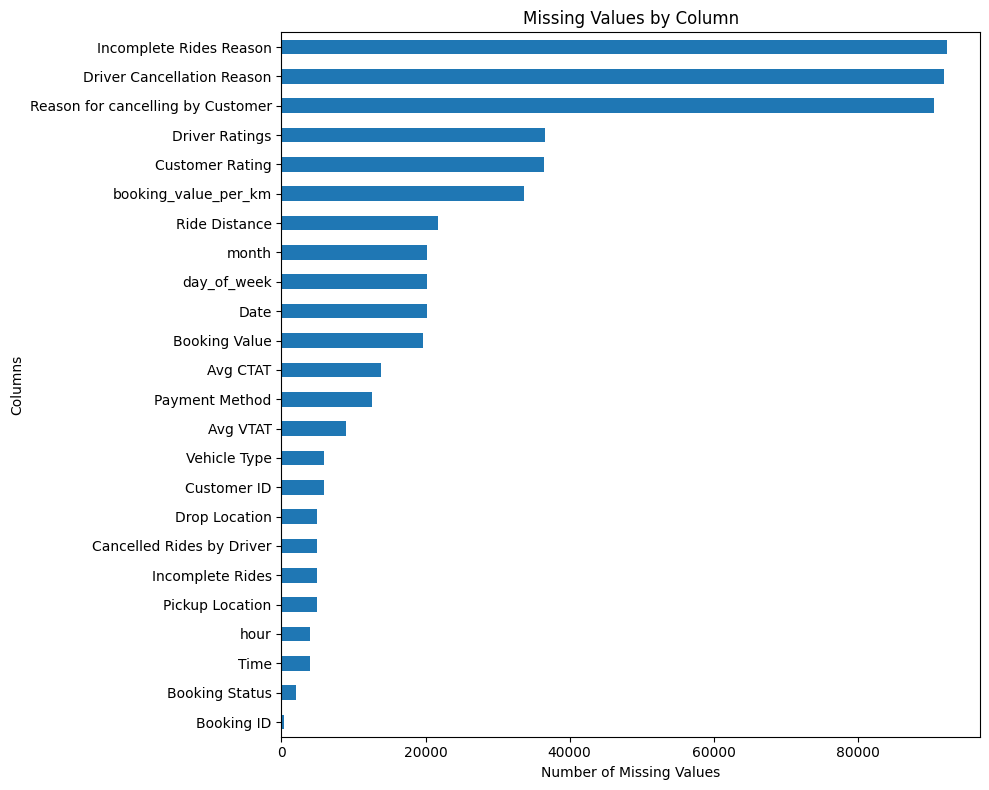

In [152]:
missing=df.isnull().sum()
missing=missing[missing>0].sort_values()

plt.figure(figsize=(10,8))
missing.plot(kind="barh")

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

### Missing Values

The bar chart shows the number of missing values present in each column. Missing values will be handled during the preprocessing stage.

In [153]:
# Standardize Booking Status

status_mapping = {
    "completed": "Completed",
    "customer cancelled": "Customer Cancelled",
    "driver cancelled": "Driver Cancelled",
    "incomplete": "Incomplete",
    "cancelled": "Cancelled"
}

df["Booking Status"] = (
    df["Booking Status"]
    .str.lower()
    .replace(status_mapping)
)

print(df["Booking Status"].value_counts(dropna=False))

Booking Status
Completed             68149
Customer Cancelled     9935
Incomplete             9610
Driver Cancelled       8339
<NA>                   1981
Cancelled              1312
Name: count, dtype: Int64


In [154]:
# Standardize Vehicle Type

vehicle_mapping = {
    "uber go": "Uber Go",
    "ubergo": "Uber Go",
    "go": "Uber Go",

    "uber auto": "Uber Auto",
    "uberauto": "Uber Auto",
    "auto": "Uber Auto",

    "uber xl": "Uber XL",
    "uberxl": "Uber XL",

    "uber premier": "Uber Premier",
    "premier": "Uber Premier",

    "moto": "Moto",
    "bike": "Bike"
}

df["Vehicle Type"] = (
    df["Vehicle Type"]
    .str.lower()
    .replace(vehicle_mapping)
)

print(df["Vehicle Type"].value_counts(dropna=False))


Vehicle Type
Uber Go         29886
Uber Auto       26192
Uber Premier    11211
Moto            11208
Bike             7480
Uber XL          7408
<NA>             5941
Name: count, dtype: Int64


In [155]:
# Standardize Payment Method

payment_mapping = {
    "upi": "UPI",
    "cash": "Cash",
    "credit card": "Credit Card",
    "creditcard": "Credit Card",
    "debit card": "Debit Card",
    "wallet": "Wallet"
}

df["Payment Method"] = (
    df["Payment Method"]
    .str.lower()
    .replace(payment_mapping)
)

print(df["Payment Method"].value_counts(dropna=False))

Payment Method
UPI            36374
Cash           17367
Credit Card    13856
<NA>           12602
Debit Card     10397
Wallet          8730
Name: count, dtype: Int64


In [156]:
# Standardize location names

location_mapping = {
    "noida sector 62": "Noida Sector 62",
    "noida sector 18": "Noida Sector 18",
    "rajouri gdn": "Rajouri Garden",
    "lajpat nagar": "Lajpat Nagar",
    "connaught plce": "Connaught Place",
    "ghaziabad": "Ghaziabad",
    "gurgaon": "Gurugram",
    "gurugram": "Gurugram",
    "delhi": "Delhi",
    "new delhi": "New Delhi"
}

for col in ["Pickup Location", "Drop Location"]:

    df[col] = (
        df[col]
        .str.strip()
        .str.lower()
        .replace(location_mapping)
    )

print("Pickup Locations:", df["Pickup Location"].nunique())
print("Drop Locations:", df["Drop Location"].nunique())

Pickup Locations: 31
Drop Locations: 31


In [157]:
# Standardize Yes/No columns

yes_no_columns = [
    "Cancelled Rides by Driver",
    "Incomplete Rides"
]

for col in yes_no_columns:
    df[col] = (
        df[col]
        .str.lower()
        .replace({
            "yes": "Yes",
            "no": "No"
        })
    )

print("Cancelled Rides by Driver:")
print(df["Cancelled Rides by Driver"].value_counts(dropna=False))

print("\nIncomplete Rides:")
print(df["Incomplete Rides"].value_counts(dropna=False))

Cancelled Rides by Driver:
Cancelled Rides by Driver
No      85748
Yes      8623
<NA>     4955
Name: count, dtype: Int64

Incomplete Rides:
Incomplete Rides
No      85038
Yes      9336
<NA>     4952
Name: count, dtype: Int64


In [158]:
# Standardize cancellation and incomplete ride reasons

reason_columns = [
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason"
]

for col in reason_columns:
    df[col] = (
        df[col]
        .str.lower()
        .str.strip()
        .str.title()
    )

print("Customer Cancellation Reasons:")
print(df["Reason for cancelling by Customer"].value_counts(dropna=False))

print("\nDriver Cancellation Reasons:")
print(df["Driver Cancellation Reason"].value_counts(dropna=False))

print("\nIncomplete Ride Reasons:")
print(df["Incomplete Rides Reason"].value_counts(dropna=False))

Customer Cancellation Reasons:
Reason for cancelling by Customer
<NA>                      90547
Other                      1279
Change Of Plans            1278
Wrong Pickup Location      1270
Wait Time Too Long         1260
Driver Is Too Far          1256
Driver Not Moving          1220
Driver Asked To Cancel     1216
Name: count, dtype: Int64

Driver Cancellation Reasons:
Driver Cancellation Reason
<NA>                        91962
Vehicle Issue                 962
Wrong Pickup Location         933
Customer Not Reachable        931
Other                         931
Too Far                       911
Traffic                       909
Personal Emergency            907
Customer Asked To Cancel      880
Name: count, dtype: Int64

Incomplete Ride Reasons:
Incomplete Rides Reason
<NA>                  92319
Route Issue            1068
Driver Emergency       1035
Trip Interrupted       1019
Technical Issue         985
Customer Emergency      977
Vehicle Breakdown       968
Other             

In [159]:
# Convert numerical columns to numeric format

numeric_columns = [
    "Avg VTAT",
    "Avg CTAT",
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.replace('"', '', regex=False)
        .str.extract(r'([-+]?\d*\.?\d+)')[0]
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print(df[numeric_columns].dtypes)

print("\nMissing values:")
print(df[numeric_columns].isna().sum())

Avg VTAT           Float64
Avg CTAT           Float64
Booking Value      Float64
Ride Distance      Float64
Driver Ratings     Float64
Customer Rating    Float64
dtype: object

Missing values:
Avg VTAT            8925
Avg CTAT           13883
Booking Value      19698
Ride Distance      21736
Driver Ratings     36546
Customer Rating    36373
dtype: int64


In [160]:
# Handle invalid Ride Distance and Booking Value

# Ride distance cannot be zero or negative
df.loc[
    df["Ride Distance"] <= 0,
    "Ride Distance"
] = np.nan

# Booking value cannot be negative
df.loc[
    df["Booking Value"] < 0,
    "Booking Value"
] = np.nan


print("Invalid Ride Distance:",
      (df["Ride Distance"] <= 0).sum())

print("Invalid Booking Value:",
      (df["Booking Value"] < 0).sum())

print("\nMissing values:")
print(
    df[["Ride Distance", "Booking Value"]]
    .isna()
    .sum()
)

Invalid Ride Distance: 0
Invalid Booking Value: 0

Missing values:
Ride Distance    21908
Booking Value    19780
dtype: int64


In [161]:
# Final data quality check

print("Final Dataset Shape:")
print(df.shape)

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nMissing Values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nVehicle Types:")
print(df["Vehicle Type"].value_counts(dropna=False))

print("\nPayment Methods:")
print(df["Payment Method"].value_counts(dropna=False))

print("\nBooking Status:")
print(df["Booking Status"].value_counts(dropna=False))

Final Dataset Shape:
(99326, 25)

Duplicate Rows:
0

Missing Values:
Incomplete Rides Reason              92319
Driver Cancellation Reason           91962
Reason for cancelling by Customer    90547
Driver Ratings                       36546
Customer Rating                      36373
booking_value_per_km                 33666
Ride Distance                        21908
day_of_week                          20263
Date                                 20263
month                                20263
Booking Value                        19780
Avg CTAT                             13883
Payment Method                       12602
Avg VTAT                              8925
Vehicle Type                          5941
Customer ID                           5872
Drop Location                         4975
Cancelled Rides by Driver             4955
Incomplete Rides                      4952
Pickup Location                       4947
Time                                  3921
hour                        

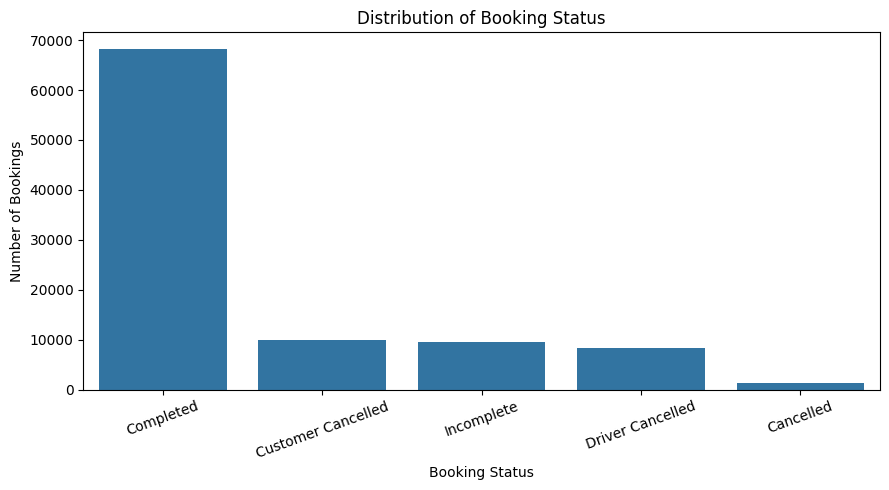

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Booking Status",
    order=df["Booking Status"].value_counts().index
)

plt.title("Distribution of Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

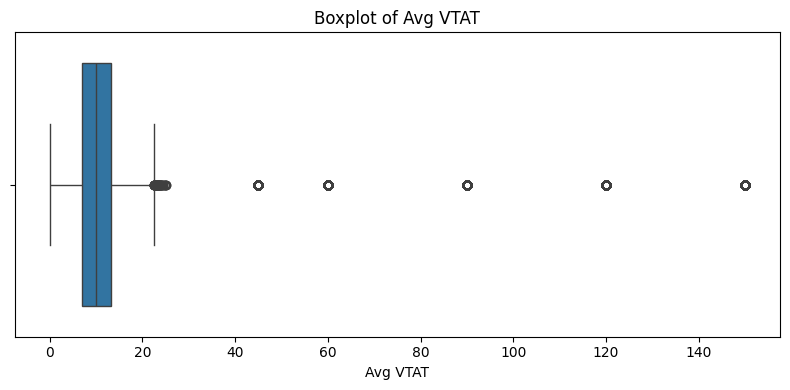

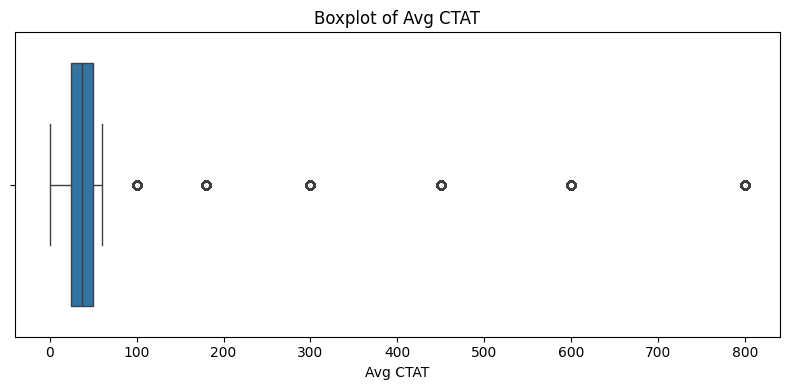

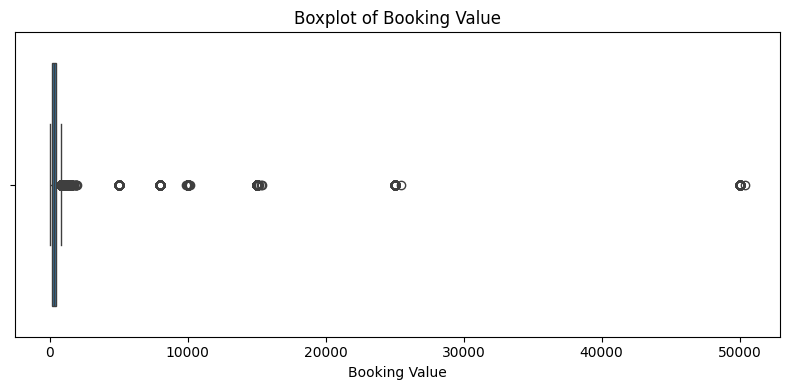

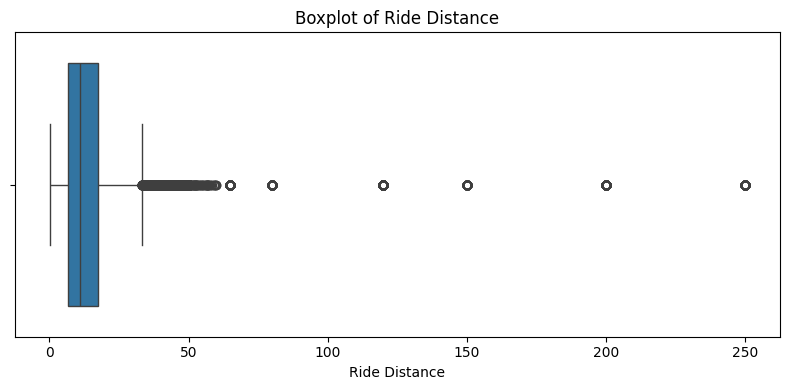

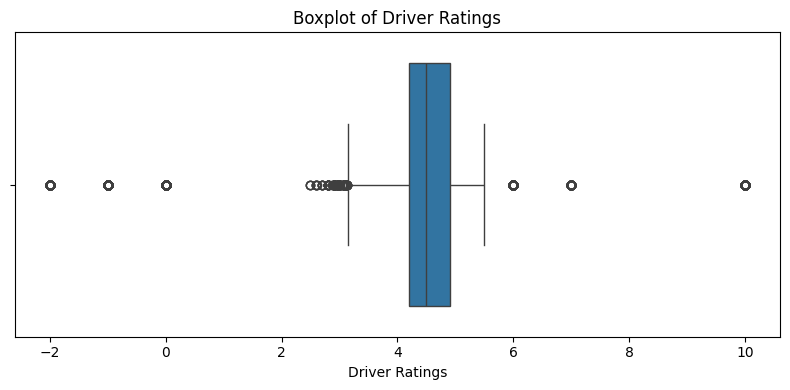

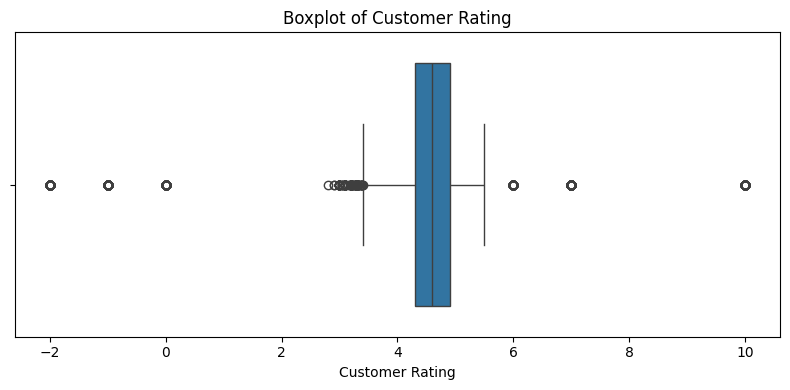

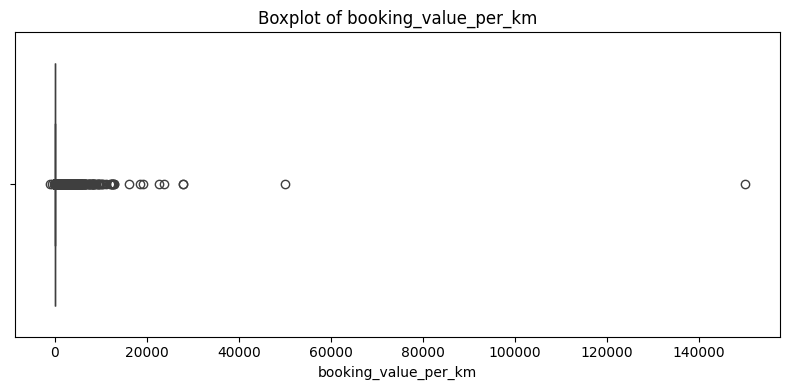

In [163]:
# Boxplots for numerical columns

numerical_columns = [
    "Avg VTAT",
    "Avg CTAT",
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating",
    "booking_value_per_km"
]

for col in numerical_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [164]:
# Count outliers using IQR method

outlier_counts = {}

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_counts[col] = len(outliers)

print("Outlier Count:")
print(pd.Series(outlier_counts).sort_values(ascending=False))

Outlier Count:
booking_value_per_km    3679
Booking Value           3179
Ride Distance           2852
Avg VTAT                1169
Avg CTAT                1093
Driver Ratings           962
Customer Rating          874
dtype: int64


In [165]:
# Treat outliers using IQR capping

outlier_columns = [
    "Avg VTAT",
    "Avg CTAT",
    "Booking Value",
    "Ride Distance",
    "booking_value_per_km"
]

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap extreme values instead of deleting rows
    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed.")

print("\nMaximum values after treatment:")
print(df[outlier_columns].max())

Outlier treatment completed.

Maximum values after treatment:
Avg VTAT                    22.5
Avg CTAT                    86.8
Booking Value             852.85
Ride Distance               33.3
booking_value_per_km    48.26275
dtype: Float64


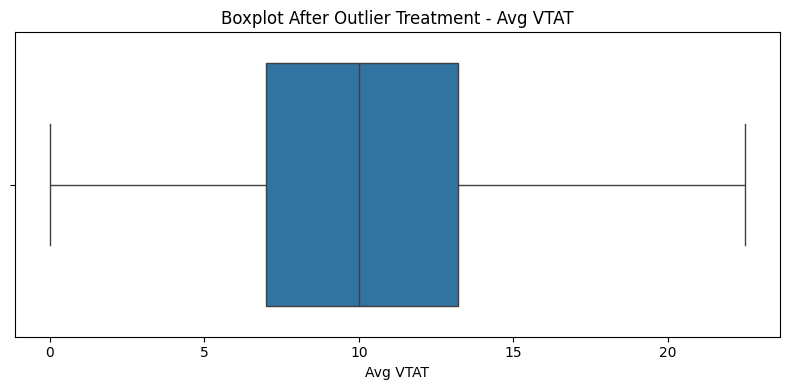

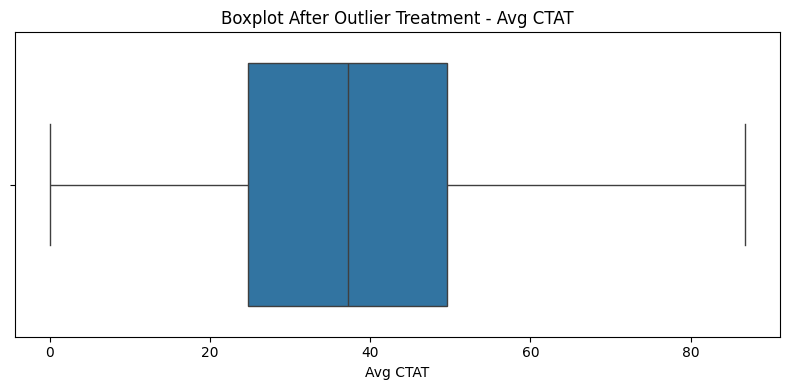

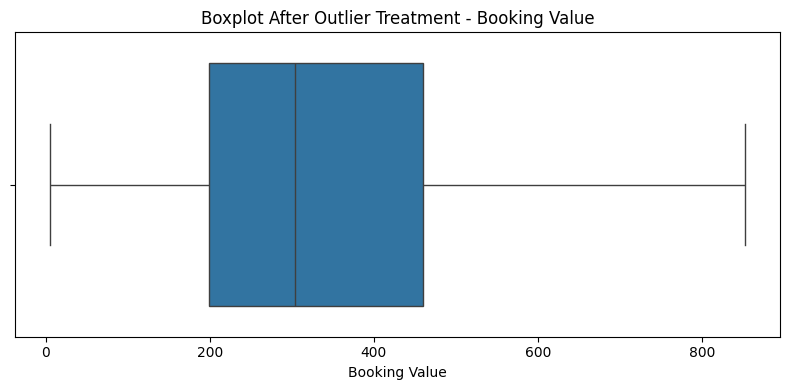

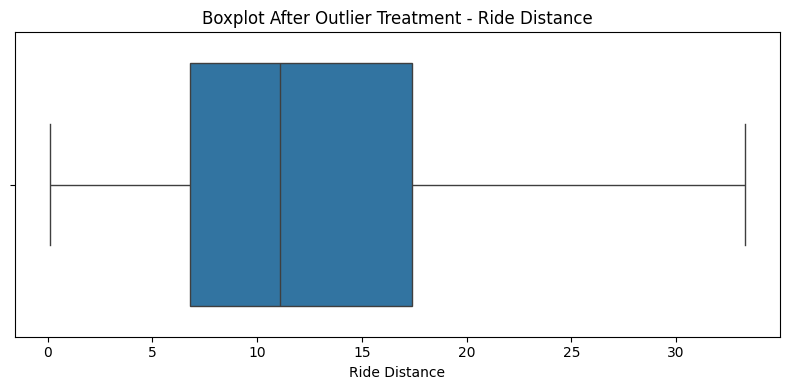

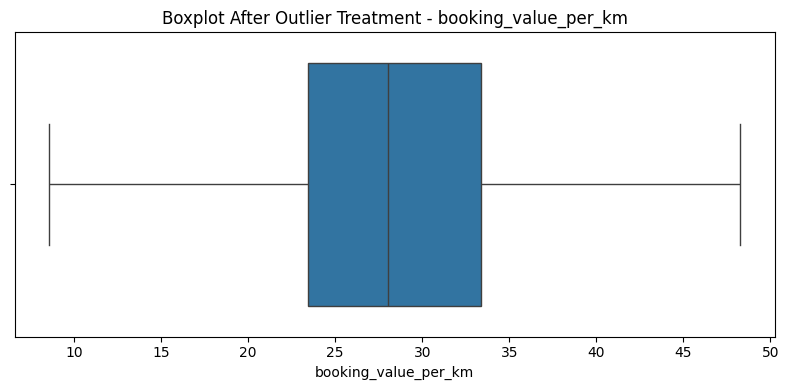

In [166]:
# Boxplots after outlier treatment

for col in outlier_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot After Outlier Treatment - {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

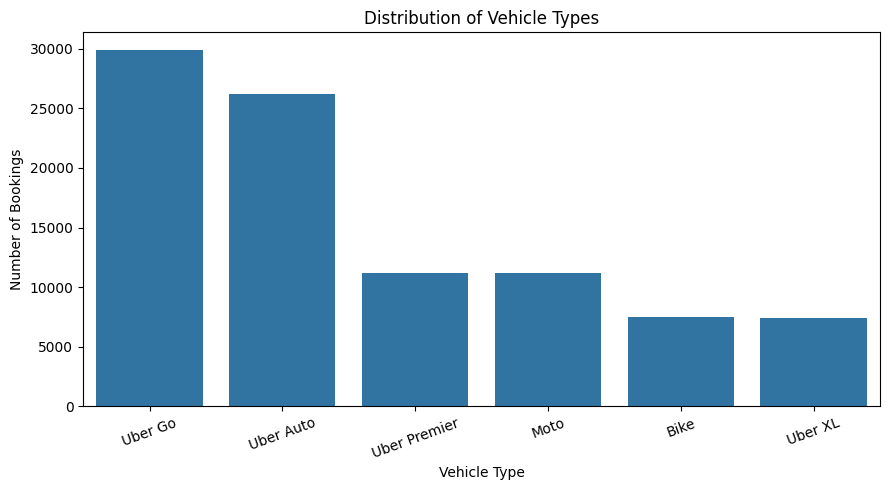

In [167]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Vehicle Type",
    order=df["Vehicle Type"].value_counts().index
)

plt.title("Distribution of Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

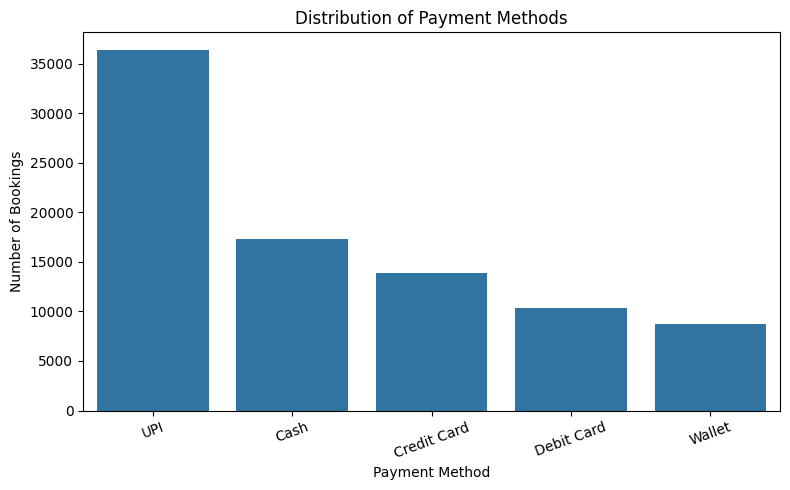

In [168]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Payment Method",
    order=df["Payment Method"].value_counts().index
)

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

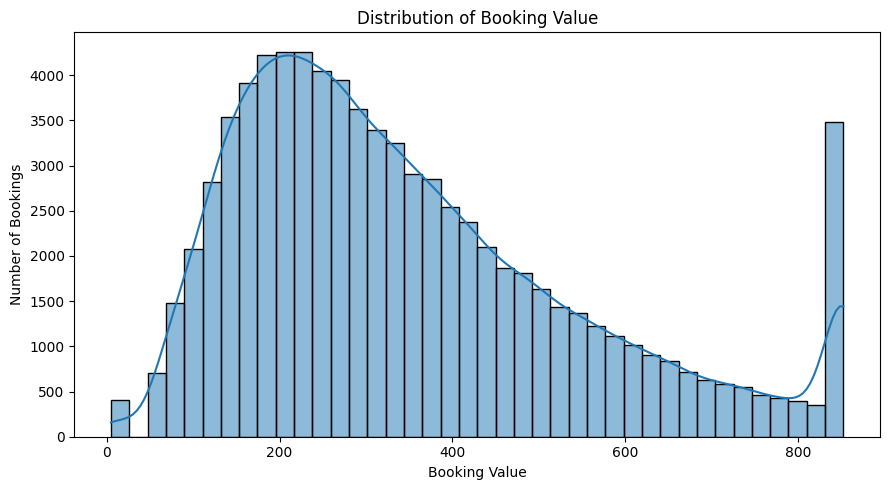

In [169]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Booking Value",
    bins=40,
    kde=True
)

plt.title("Distribution of Booking Value")
plt.xlabel("Booking Value")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()

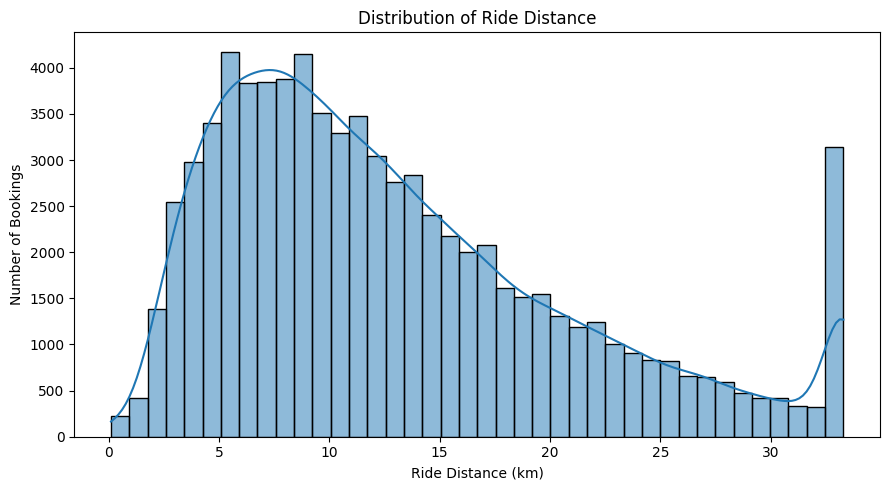

In [170]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Ride Distance",
    bins=40,
    kde=True
)

plt.title("Distribution of Ride Distance")
plt.xlabel("Ride Distance (km)")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()

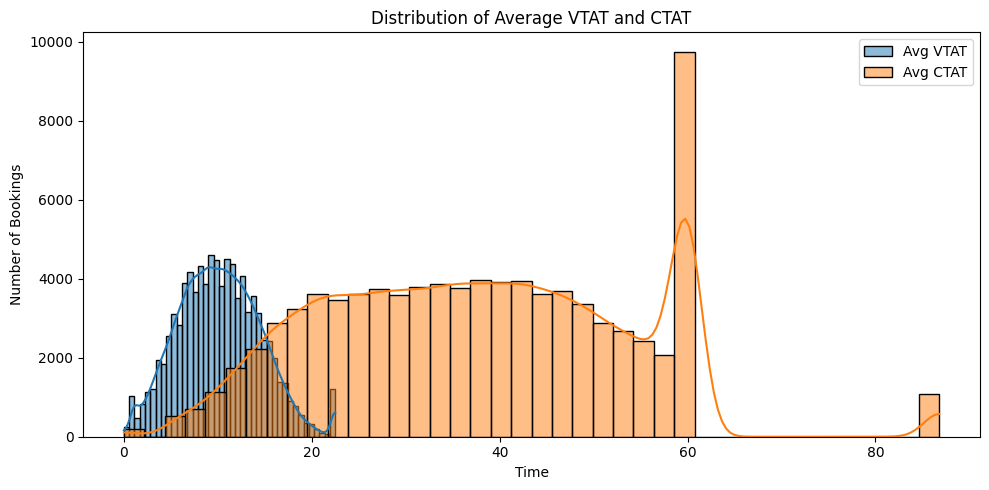

In [171]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Avg VTAT"],
    bins=40,
    kde=True,
    label="Avg VTAT",
    alpha=0.5
)

sns.histplot(
    df["Avg CTAT"],
    bins=40,
    kde=True,
    label="Avg CTAT",
    alpha=0.5
)

plt.title("Distribution of Average VTAT and CTAT")
plt.xlabel("Time")
plt.ylabel("Number of Bookings")
plt.legend()

plt.tight_layout()
plt.show()

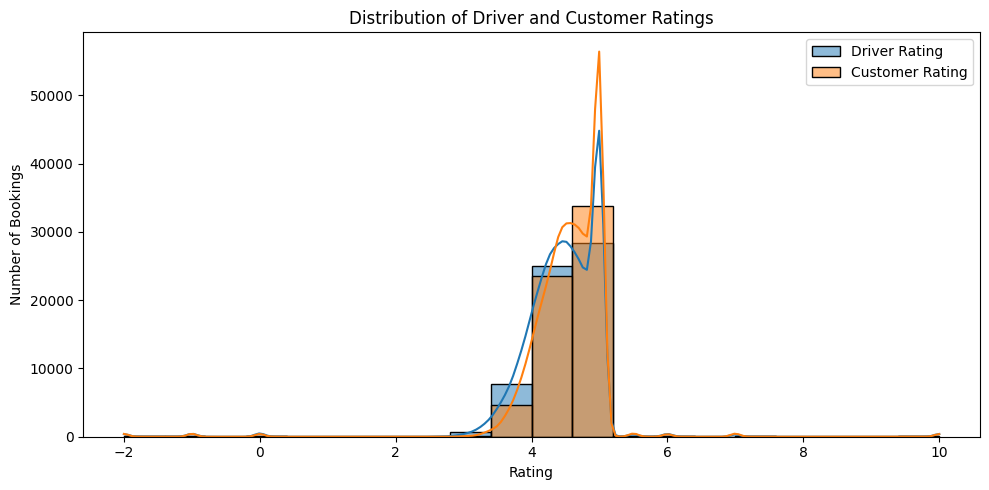

In [172]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Driver Ratings"],
    bins=20,
    kde=True,
    label="Driver Rating",
    alpha=0.5
)

sns.histplot(
    df["Customer Rating"],
    bins=20,
    kde=True,
    label="Customer Rating",
    alpha=0.5
)

plt.title("Distribution of Driver and Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Bookings")
plt.legend()

plt.tight_layout()
plt.show()

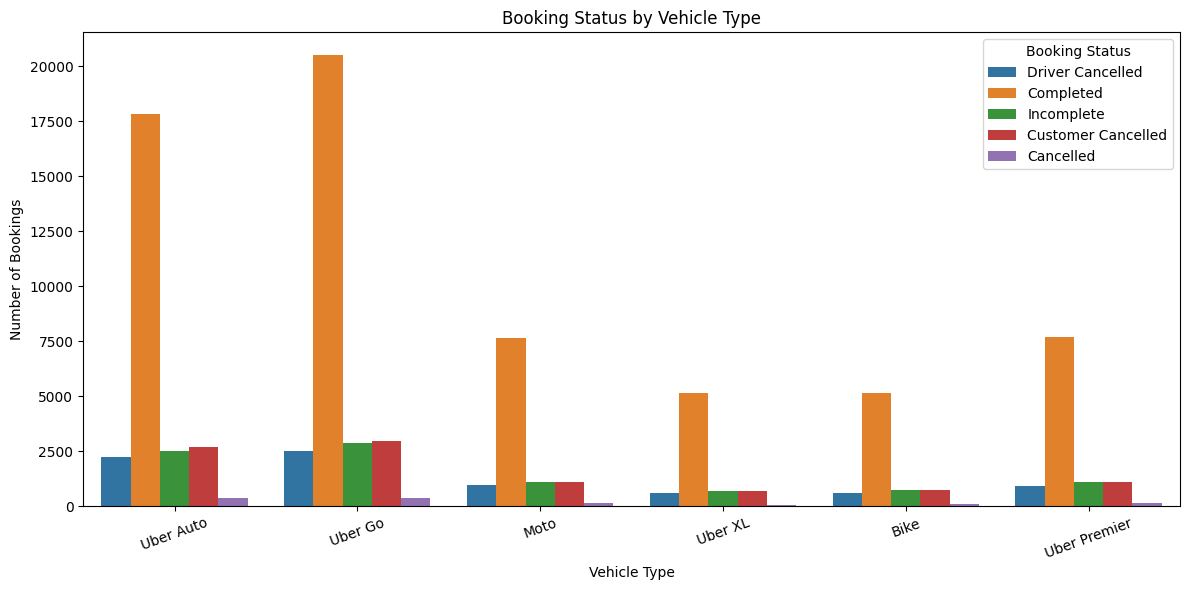

In [173]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Vehicle Type",
    hue="Booking Status"
)

plt.title("Booking Status by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)
plt.legend(title="Booking Status")

plt.tight_layout()
plt.show()

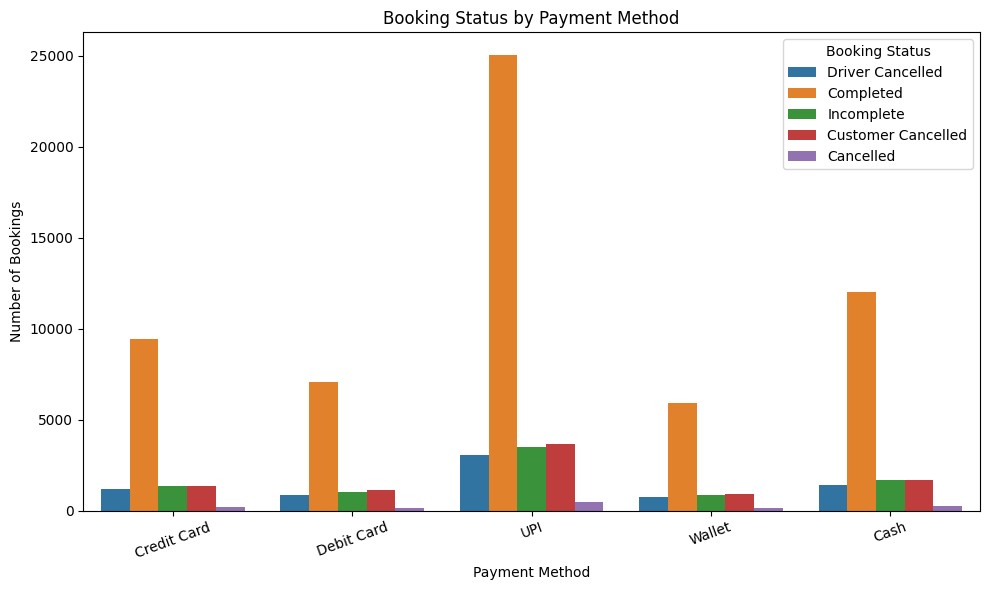

In [174]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Booking Status"
)

plt.title("Booking Status by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)
plt.legend(title="Booking Status")

plt.tight_layout()
plt.show()

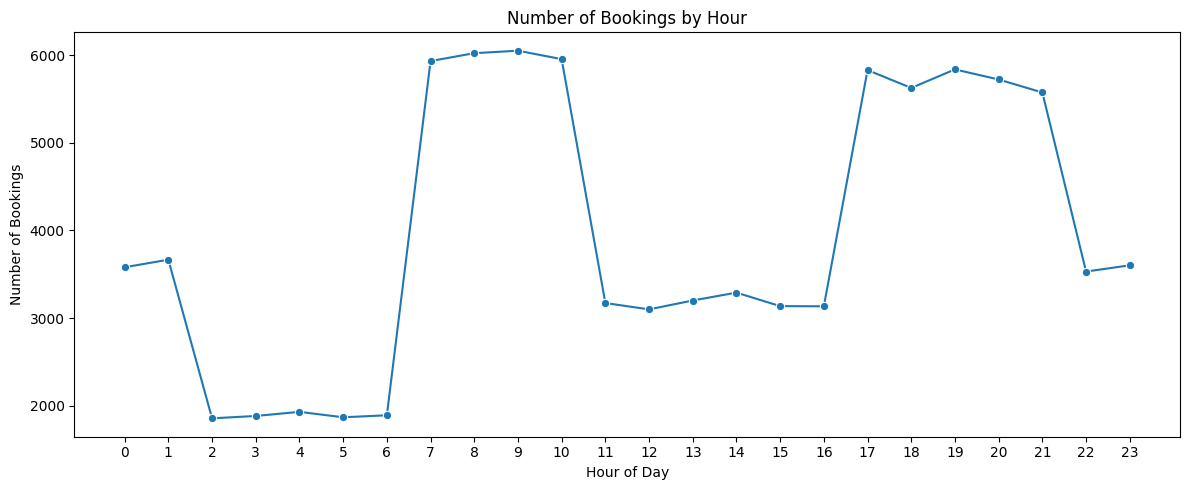

In [175]:
hourly_bookings = df["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_bookings.index,
    y=hourly_bookings.values,
    marker="o"
)

plt.title("Number of Bookings by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bookings")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

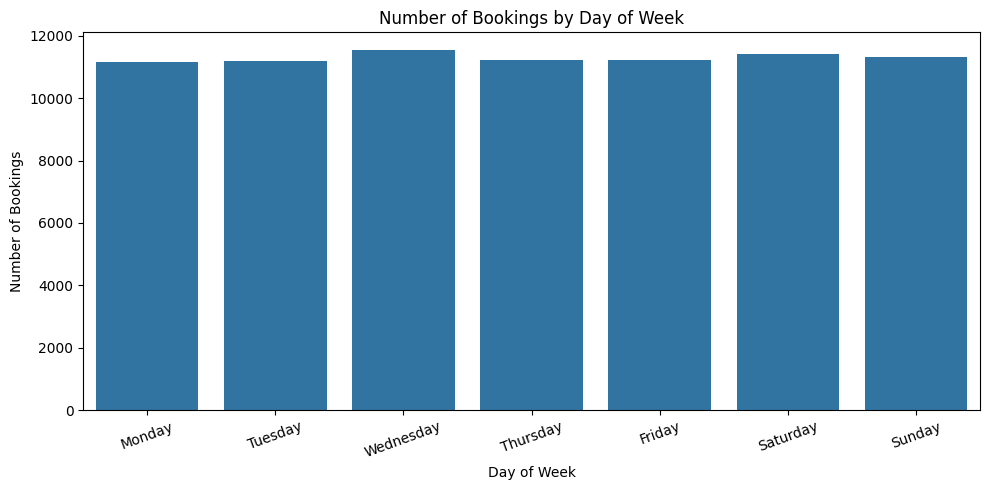

In [176]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_bookings = (
    df["day_of_week"]
    .map(day_names)
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_bookings.index,
    y=day_bookings.values
)

plt.title("Number of Bookings by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

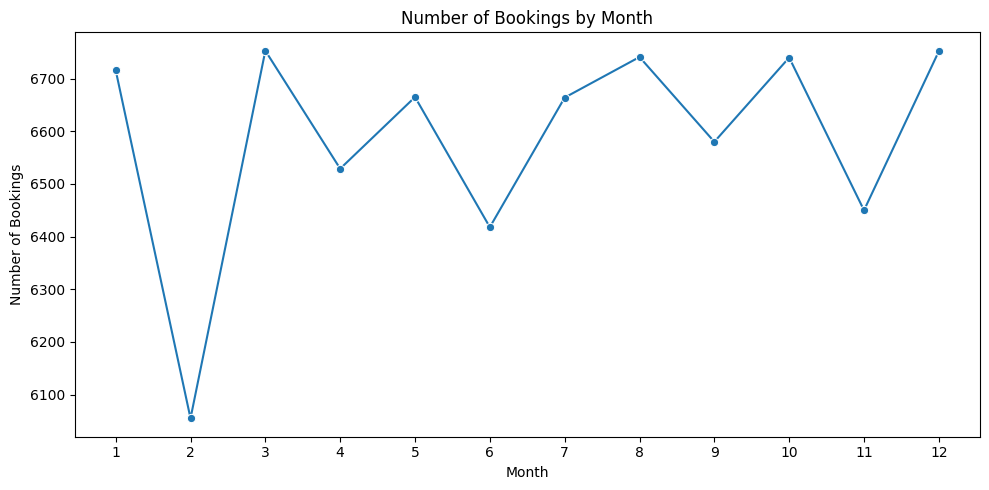

In [177]:
monthly_bookings = (
    df["month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_bookings.index,
    y=monthly_bookings.values,
    marker="o"
)

plt.title("Number of Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

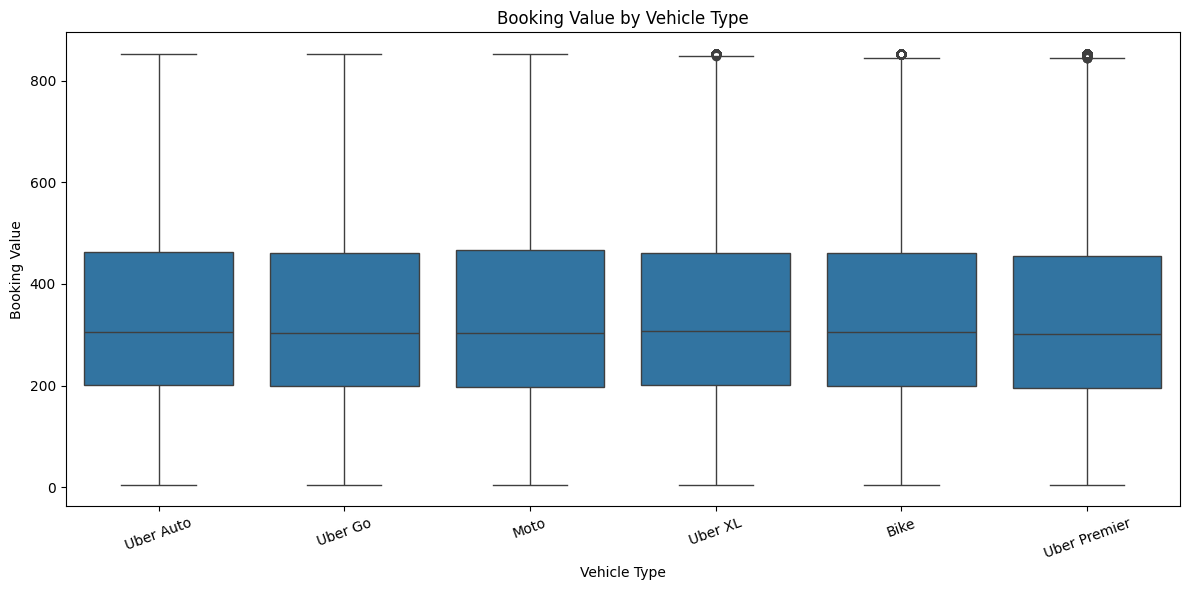

In [178]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Vehicle Type",
    y="Booking Value"
)

plt.title("Booking Value by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Booking Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

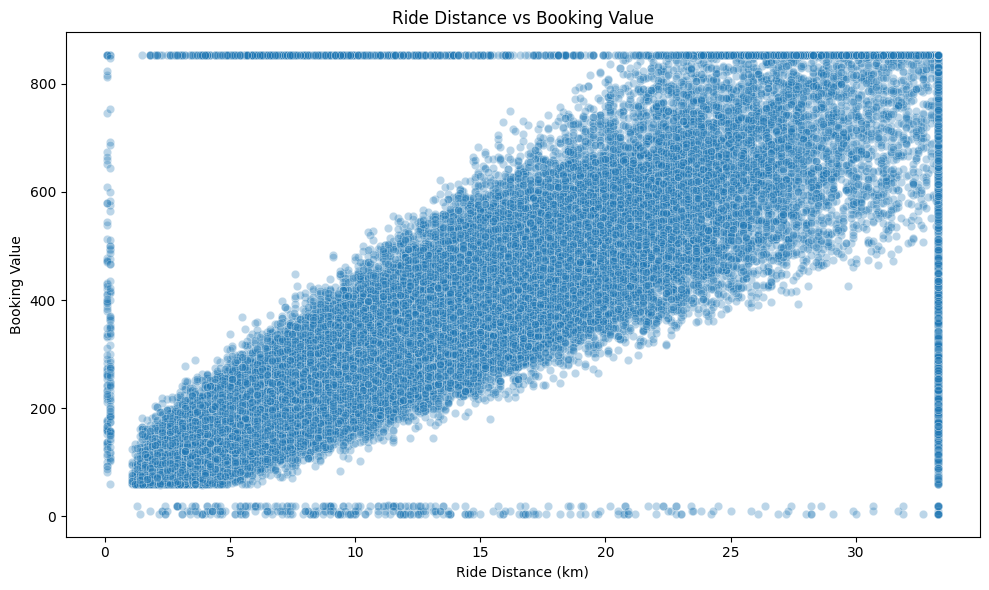

In [179]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Ride Distance",
    y="Booking Value",
    alpha=0.3
)

plt.title("Ride Distance vs Booking Value")
plt.xlabel("Ride Distance (km)")
plt.ylabel("Booking Value")

plt.tight_layout()
plt.show()

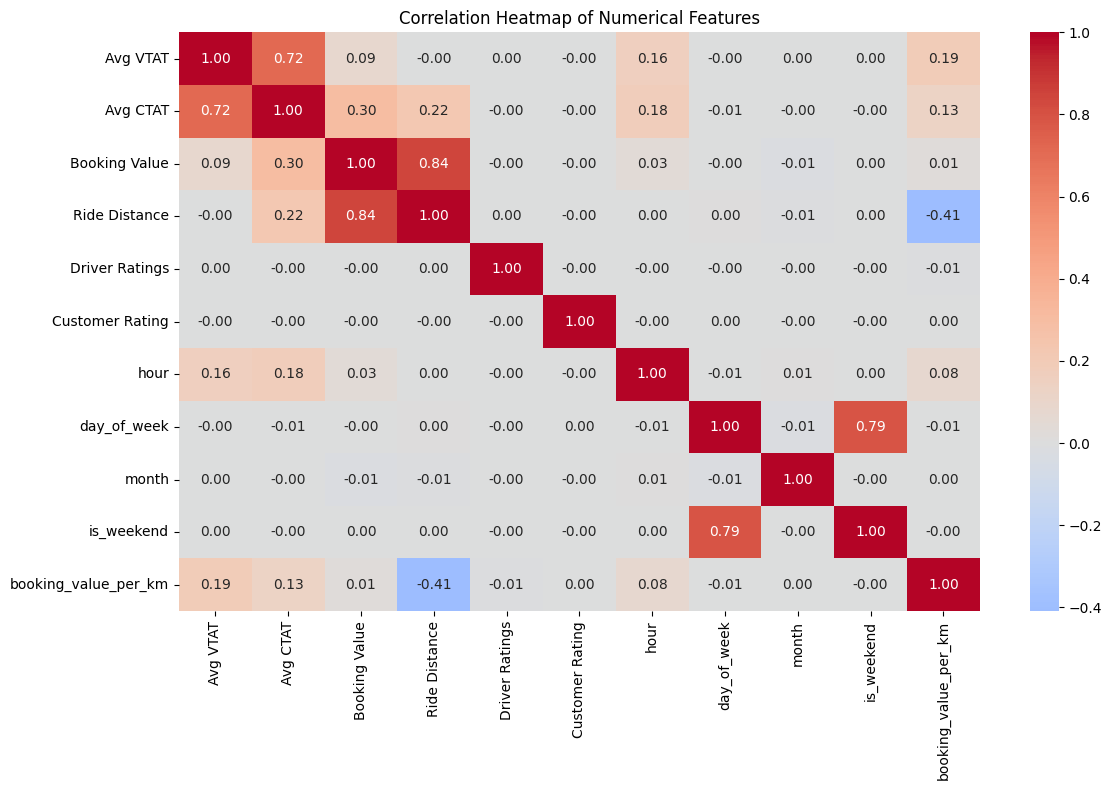

In [180]:
# Select numerical columns
correlation_data = df.select_dtypes(include="number")

# Calculate correlation
correlation_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [181]:
target_correlation = (
    df.select_dtypes(include="number")
      .corr()["Booking Value"]
      .drop("Booking Value")
      .sort_values(ascending=False)
)

print("Correlation with Booking Value:")
print(target_correlation)

Correlation with Booking Value:
Ride Distance           0.844982
Avg CTAT                0.302887
Avg VTAT                0.085218
hour                    0.034921
booking_value_per_km    0.014743
is_weekend              0.002696
day_of_week            -0.000848
Customer Rating        -0.003055
Driver Ratings         -0.004164
month                  -0.014280
Name: Booking Value, dtype: float64


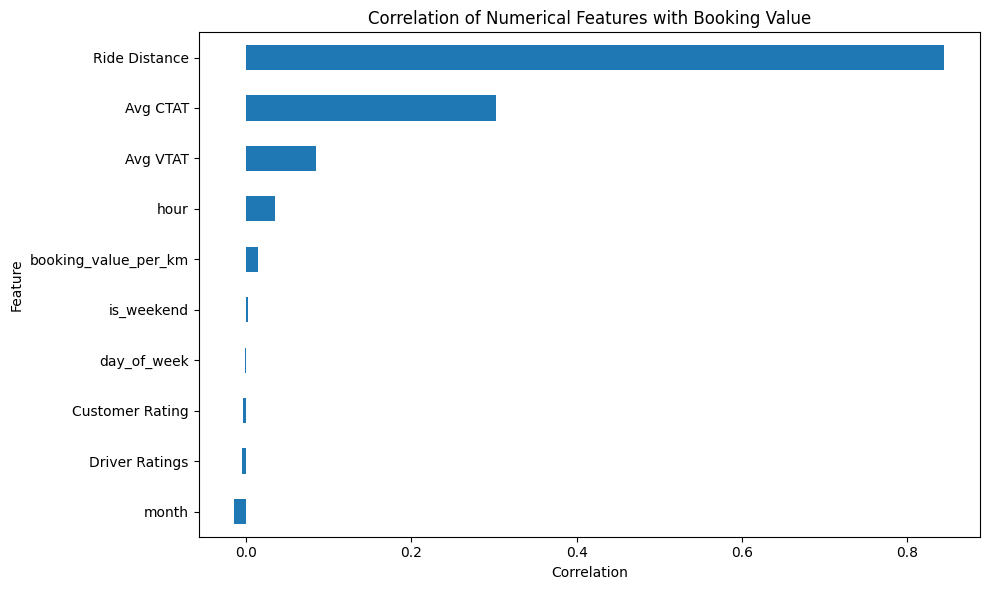

In [182]:
plt.figure(figsize=(10, 6))

target_correlation.sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Numerical Features with Booking Value")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

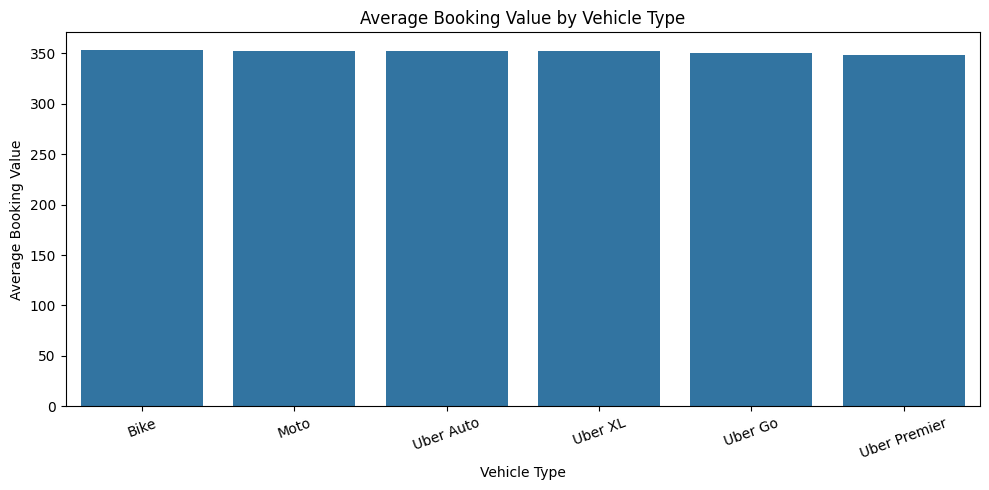

In [183]:
vehicle_booking_value = (
    df.groupby("Vehicle Type")["Booking Value"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=vehicle_booking_value.index,
    y=vehicle_booking_value.values
)

plt.title("Average Booking Value by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Booking Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

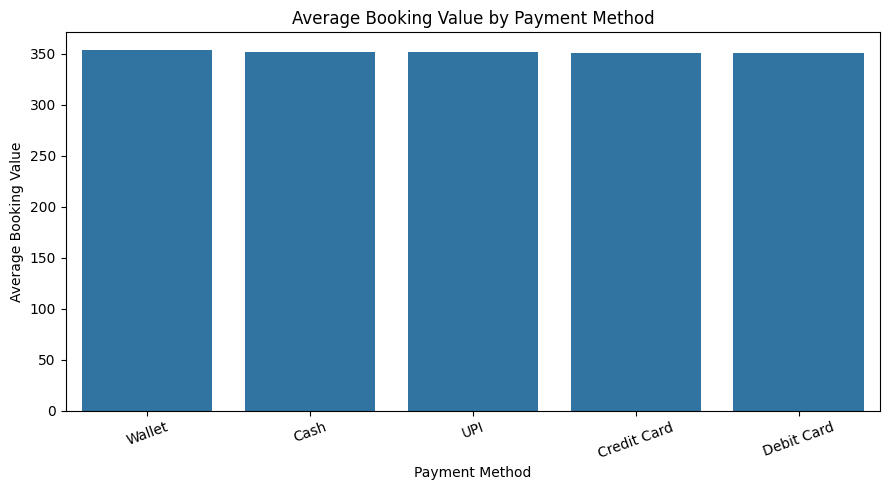

In [184]:
payment_booking_value = (
    df.groupby("Payment Method")["Booking Value"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_booking_value.index,
    y=payment_booking_value.values
)

plt.title("Average Booking Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Booking Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

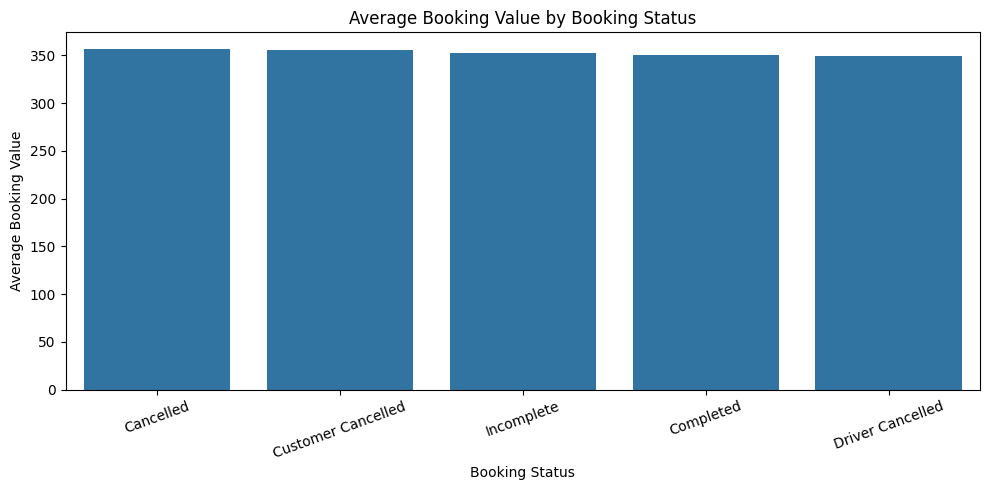

In [185]:
status_booking_value = (
    df.groupby("Booking Status")["Booking Value"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=status_booking_value.index,
    y=status_booking_value.values
)

plt.title("Average Booking Value by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Booking Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

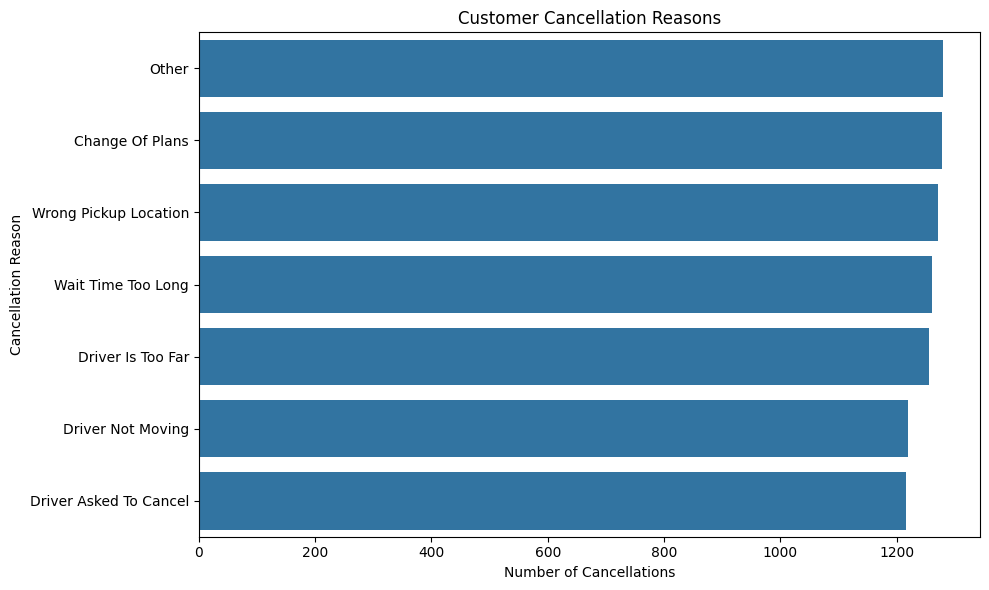

In [186]:
customer_cancel_reasons = (
    df["Reason for cancelling by Customer"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=customer_cancel_reasons.values,
    y=customer_cancel_reasons.index
)

plt.title("Customer Cancellation Reasons")
plt.xlabel("Number of Cancellations")
plt.ylabel("Cancellation Reason")

plt.tight_layout()
plt.show()

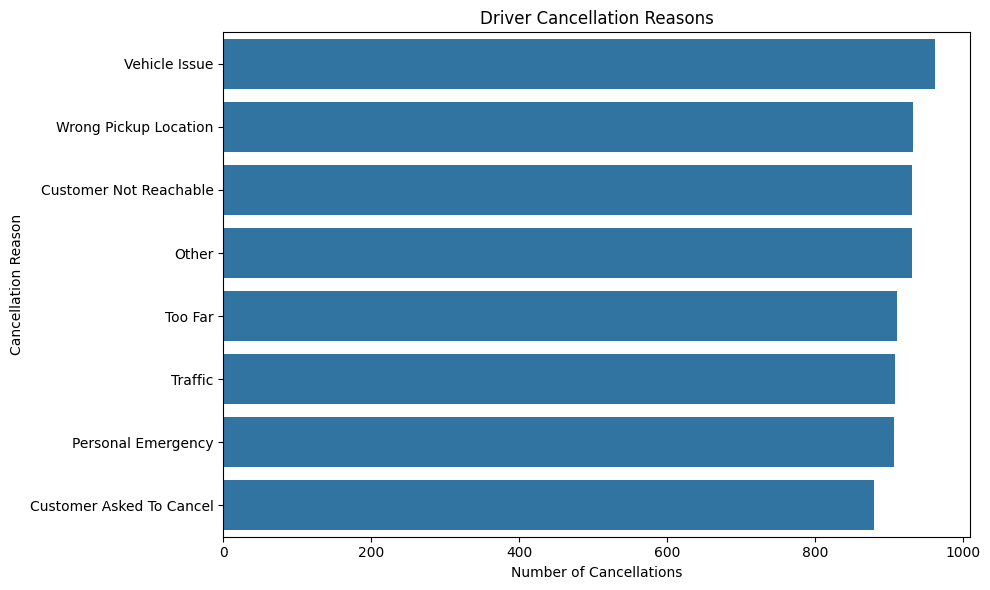

In [187]:
driver_cancel_reasons = (
    df["Driver Cancellation Reason"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=driver_cancel_reasons.values,
    y=driver_cancel_reasons.index
)

plt.title("Driver Cancellation Reasons")
plt.xlabel("Number of Cancellations")
plt.ylabel("Cancellation Reason")

plt.tight_layout()
plt.show()

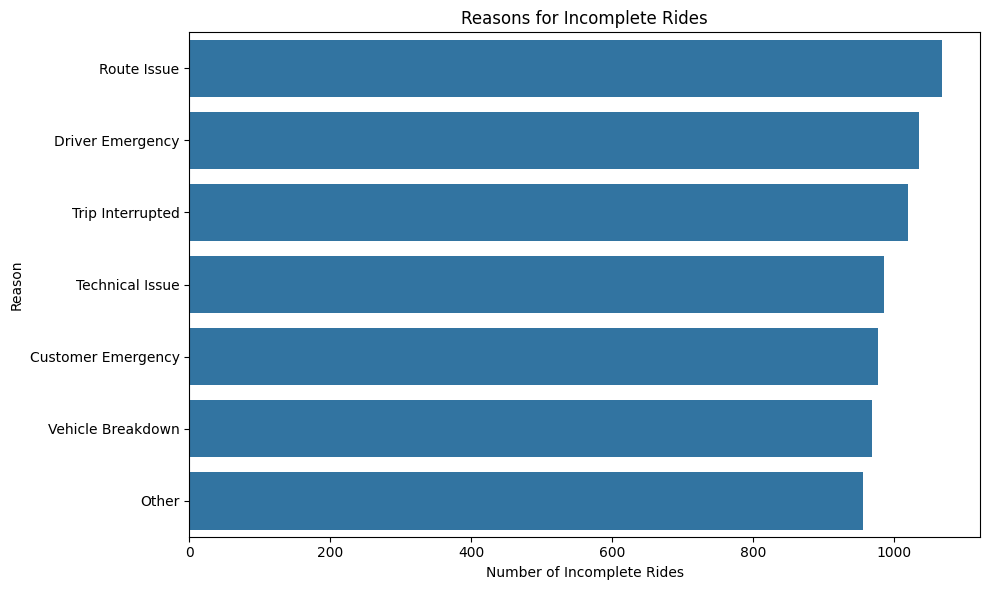

In [188]:
incomplete_reasons = (
    df["Incomplete Rides Reason"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=incomplete_reasons.values,
    y=incomplete_reasons.index
)

plt.title("Reasons for Incomplete Rides")
plt.xlabel("Number of Incomplete Rides")
plt.ylabel("Reason")

plt.tight_layout()
plt.show()

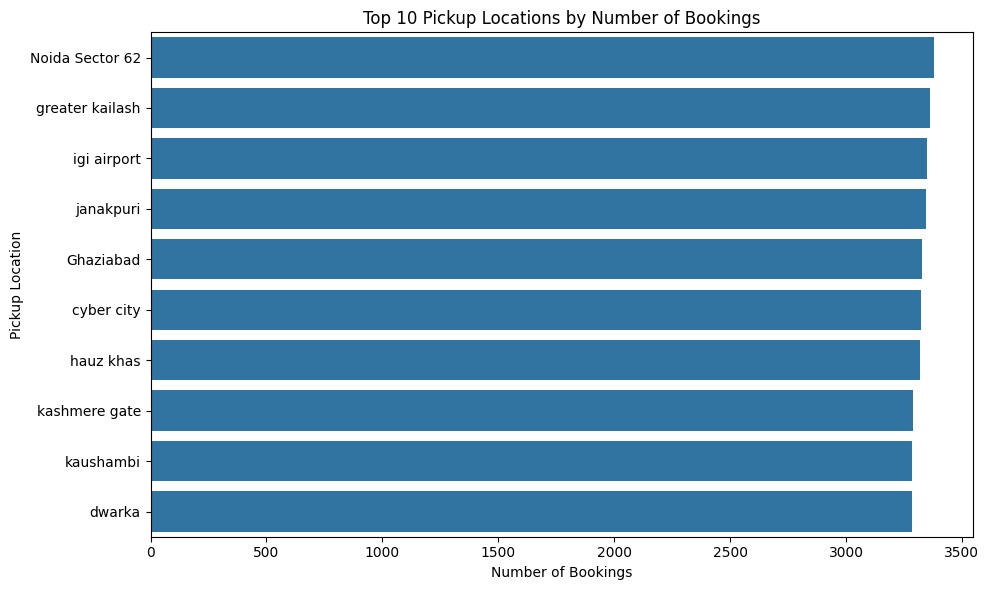

In [189]:
top_pickup_locations = (
    df["Pickup Location"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_pickup_locations.values,
    y=top_pickup_locations.index
)

plt.title("Top 10 Pickup Locations by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Pickup Location")

plt.tight_layout()
plt.show()

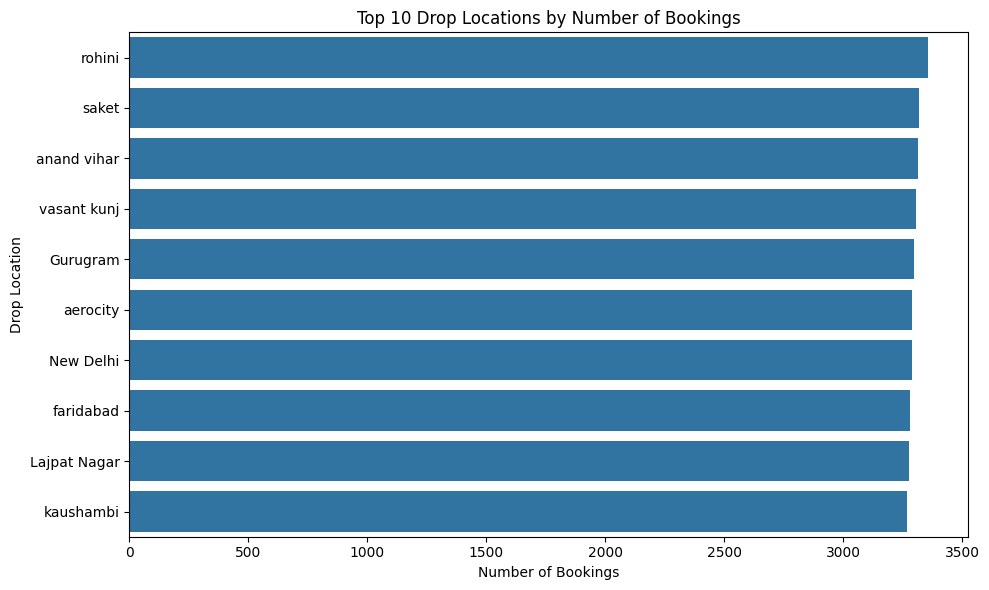

In [190]:
top_drop_locations = (
    df["Drop Location"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_drop_locations.values,
    y=top_drop_locations.index
)

plt.title("Top 10 Drop Locations by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Drop Location")

plt.tight_layout()
plt.show()

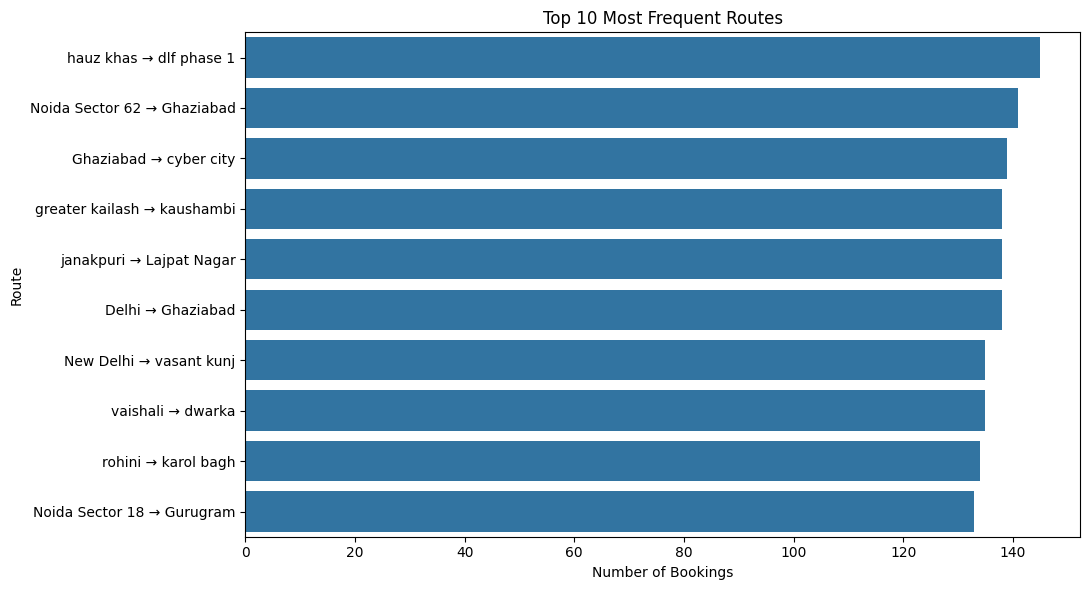

In [191]:
top_routes = (
    df.dropna(subset=["Pickup Location", "Drop Location"])
      .groupby(["Pickup Location", "Drop Location"])
      .size()
      .sort_values(ascending=False)
      .head(10)
)

route_labels = [
    f"{pickup} → {drop}"
    for pickup, drop in top_routes.index
]

plt.figure(figsize=(11, 6))

sns.barplot(
    x=top_routes.values,
    y=route_labels
)

plt.title("Top 10 Most Frequent Routes")
plt.xlabel("Number of Bookings")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

## Machine Learning

After completing the exploratory data analysis, machine learning models are developed to predict the **Booking Value** of an Uber ride.

Since Booking Value is a continuous numerical variable, this is treated as a **Regression Problem**.

The following steps will be performed:

1. Define the target variable and features
2. Handle missing values
3. Encode categorical features
4. Split the data into training and testing sets
5. Train multiple regression models
6. Evaluate model performance
7. Compare the models using MAE, MSE, RMSE, and R² Score
8. Select the model based on the evaluation results
9. Perform error analysis on the predictions

In [192]:
# Define target variable and features

target = "Booking Value"

features = [
    "Vehicle Type",
    "Pickup Location",
    "Drop Location",
    "Avg VTAT",
    "Avg CTAT",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating",
    "Payment Method",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

X = df[features].copy()
y = df[target].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(features)

print("\nTarget:", target)

Features shape: (99326, 13)
Target shape: (99326,)

Features:
['Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'hour', 'day_of_week', 'month', 'is_weekend']

Target: Booking Value


## Train-Test Split

The dataset is divided into training and testing sets.

- **Training data (80%)** is used to train the machine learning models.
- **Testing data (20%)** is used to evaluate how well the trained models perform on unseen data.

The split is performed before model-specific preprocessing to avoid data leakage.

In [193]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (79460, 13)
Testing Features: (19866, 13)
Training Target: (79460,)
Testing Target: (19866,)


## Data Preprocessing

Machine learning models cannot directly work with missing values and categorical text data.

Therefore, the following preprocessing steps are applied:

1. Fill missing numerical values using the median.
2. Fill missing categorical values using the most frequent value.
3. Convert categorical variables into numerical form using One-Hot Encoding.
4. Standardize numerical features using StandardScaler.

A `ColumnTransformer` is used so that the same preprocessing can be applied consistently to training and testing data.

## Model Training and Comparison

Two regression models are trained to predict the Booking Value:

1. Linear Regression
2. Random Forest Regressor

Linear Regression is used as a simple baseline model, while Random Forest is used to capture more complex and non-linear relationships in the data.

In [194]:
print(type(preprocessor))
print(X_train.shape)
print(y_train.shape)

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
(79460, 13)
(79460,)


In [195]:
# Make sure numerical columns are numeric

for col in numerical_features:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

print(X_train[numerical_features].dtypes)

Avg VTAT           Float64
Avg CTAT           Float64
Ride Distance      Float64
Driver Ratings     Float64
Customer Rating    Float64
hour               float64
day_of_week        float64
month              float64
is_weekend           int64
dtype: object


In [196]:
print("X_train dtypes:")
print(X_train.dtypes)

print("\nObject columns:")
print(X_train.select_dtypes(include=["object"]).columns.tolist())

print("\nX_train shape:", X_train.shape)
print("y_train dtype:", y_train.dtype)

X_train dtypes:
Vehicle Type       string[python]
Pickup Location    string[python]
Drop Location      string[python]
Avg VTAT                  Float64
Avg CTAT                  Float64
Ride Distance             Float64
Driver Ratings            Float64
Customer Rating           Float64
Payment Method     string[python]
hour                      float64
day_of_week               float64
month                     float64
is_weekend                  int64
dtype: object

Object columns:
[]

X_train shape: (79460, 13)
y_train dtype: Float64


In [197]:
print("Missing values in numerical columns:")
print(X_train[numerical_features].isna().sum())

print("\nMissing values in categorical columns:")
print(X_train[categorical_features].isna().sum())

Missing values in numerical columns:
Avg VTAT            7121
Avg CTAT           11084
Ride Distance      17466
Driver Ratings     29209
Customer Rating    29115
hour                3136
day_of_week        16185
month              16185
is_weekend             0
dtype: int64

Missing values in categorical columns:
Vehicle Type        4724
Pickup Location     3962
Drop Location       3963
Payment Method     10139
dtype: int64


In [198]:
print("Unique data types in numerical columns:")

for col in numerical_features:
    print(col, X_train[col].apply(type).value_counts().to_dict())

Unique data types in numerical columns:
Avg VTAT {<class 'float'>: 79460}
Avg CTAT {<class 'float'>: 79460}
Ride Distance {<class 'float'>: 79460}
Driver Ratings {<class 'float'>: 79460}
Customer Rating {<class 'float'>: 79460}
hour {<class 'float'>: 79460}
day_of_week {<class 'float'>: 79460}
month {<class 'float'>: 79460}
is_weekend {<class 'int'>: 79460}


In [199]:
print("Unique data types in categorical columns:")

for col in categorical_features:
    print("\n", col)
    print(X_train[col].apply(type).value_counts().to_dict())

Unique data types in categorical columns:

 Vehicle Type
{<class 'str'>: 74736, <class 'pandas._libs.missing.NAType'>: 4724}

 Pickup Location
{<class 'str'>: 75498, <class 'pandas._libs.missing.NAType'>: 3962}

 Drop Location
{<class 'str'>: 75497, <class 'pandas._libs.missing.NAType'>: 3963}

 Payment Method
{<class 'str'>: 69321, <class 'pandas._libs.missing.NAType'>: 10139}


In [211]:
# Convert categorical columns to normal object dtype
for col in categorical_features:
    X_train[col] = X_train[col].astype(object)
    X_test[col] = X_test[col].astype(object)

# Convert numerical columns to normal float dtype
for col in numerical_features:
    X_train[col] = X_train[col].astype(float)
    X_test[col] = X_test[col].astype(float)

print("Data types converted successfully.")
print(X_train.dtypes)

Data types converted successfully.
Vehicle Type        object
Pickup Location     object
Drop Location       object
Avg VTAT           float64
Avg CTAT           float64
Ride Distance      float64
Driver Ratings     float64
Customer Rating    float64
Payment Method      object
hour               float64
day_of_week        float64
month              float64
is_weekend         float64
dtype: object


In [214]:
import numpy as np

# Convert pandas NA values to NumPy NaN
X_train = X_train.replace({pd.NA: np.nan})
X_test = X_test.replace({pd.NA: np.nan})

# Make categorical columns normal object dtype
for col in categorical_features:
    X_train[col] = X_train[col].astype(object)
    X_test[col] = X_test[col].astype(object)

# Make numerical columns normal float dtype
for col in numerical_features:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce").astype(float)
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce").astype(float)

print("pd.NA converted to np.nan successfully!")

pd.NA converted to np.nan successfully!


In [215]:
print("Remaining pd.NA in X_train:", X_train.isna().sum().sum())
print("Remaining pd.NA in X_test:", X_test.isna().sum().sum())

print("\nData types:")
print(X_train.dtypes)

Remaining pd.NA in X_train: 109093
Remaining pd.NA in X_test: 27529

Data types:
Vehicle Type        object
Pickup Location     object
Drop Location       object
Avg VTAT           float64
Avg CTAT           float64
Ride Distance      float64
Driver Ratings     float64
Customer Rating    float64
Payment Method      object
hour               float64
day_of_week        float64
month              float64
is_weekend         float64
dtype: object


In [216]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor ready!")

Preprocessor ready!


In [217]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [218]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [219]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Predictions
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

# Calculate metrics
results = []

# Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

results.append({
    "Model": "Linear Regression",
    "MAE": mae_linear,
    "MSE": mse_linear,
    "RMSE": rmse_linear,
    "R² Score": r2_linear
})

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

results.append({
    "Model": "Random Forest",
    "MAE": mae_rf,
    "MSE": mse_rf,
    "RMSE": rmse_rf,
    "R² Score": r2_rf
})

# Create comparison table
results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,83.516632,15701.873392,125.307116,0.608713
1,Random Forest,77.185982,13234.600905,115.041735,0.670197


In [220]:
# Create error analysis dataframe

error_data = X_test.copy()

error_data["Actual"] = y_test
error_data["Predicted"] = y_pred_rf

# Calculate error
error_data["Error"] = (
    error_data["Actual"] - error_data["Predicted"]
)

# Calculate absolute error
error_data["Absolute Error"] = (
    error_data["Error"].abs()
)

# Show predictions with largest errors
error_data = error_data.sort_values(
    "Absolute Error",
    ascending=False
)

print("Top 10 predictions with highest errors:")
display(error_data.head(10))

Top 10 predictions with highest errors:


,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Ride Distance,Driver Ratings,Customer Rating,Payment Method,hour,day_of_week,month,is_weekend,Actual,Predicted,Error,Absolute Error
92071,Uber Premier,connaught place,Delhi,11.0,55.3,33.3,4.19462,5.000000,UPI,9.0,5.0,1.0,1.0,5.0,815.473624,-810.473624,810.473624
77482,Uber Go,igi airport,NaN,NaN,60.0,31.9,NaN,NaN,Debit Card,7.0,0.0,3.0,0.0,20.0,809.547430,-789.54743,789.54743
82742,Uber Auto,greater kailash,cyber city,3.4,8.8,2.6,NaN,NaN,UPI,3.0,5.0,11.0,1.0,852.85,90.318278,762.531722,762.531722
60752,Bike,New Delhi,vaishali,NaN,5.0,2.8,3.30000,3.500000,Debit Card,22.0,1.0,11.0,0.0,852.85,99.326426,753.523574,753.523574
48673,Uber Go,Noida Sector 18,vasant kunj,9.2,42.9,2.1,NaN,NaN,Cash,19.0,3.0,11.0,0.0,852.85,103.748612,749.101388,749.101388
94150,Moto,saket,vasant kunj,9.9,35.8,2.9,4.60000,4.397409,UPI,9.0,2.0,12.0,0.0,852.85,107.671834,745.178166,745.178166
59885,NaN,greater kailash,NaN,10.1,26.4,2.7,NaN,4.600000,Cash,11.0,5.0,12.0,1.0,852.85,109.171131,743.678869,743.678869
87489,Uber Auto,dwarka,vasant kunj,10.7,37.5,3.2,4.60000,4.220371,UPI,23.0,3.0,3.0,0.0,852.85,122.191818,730.658182,730.658182
75761,Uber Go,karol bagh,dwarka,14.7,45.7,2.9,NaN,5.000000,NaN,9.0,5.0,4.0,1.0,852.85,128.288195,724.561805,724.561805
7142,Uber Premier,NaN,cyber city,15.8,60.0,3.4,4.20000,5.000000,NaN,8.0,4.0,10.0,0.0,852.85,135.139071,717.710929,717.710929


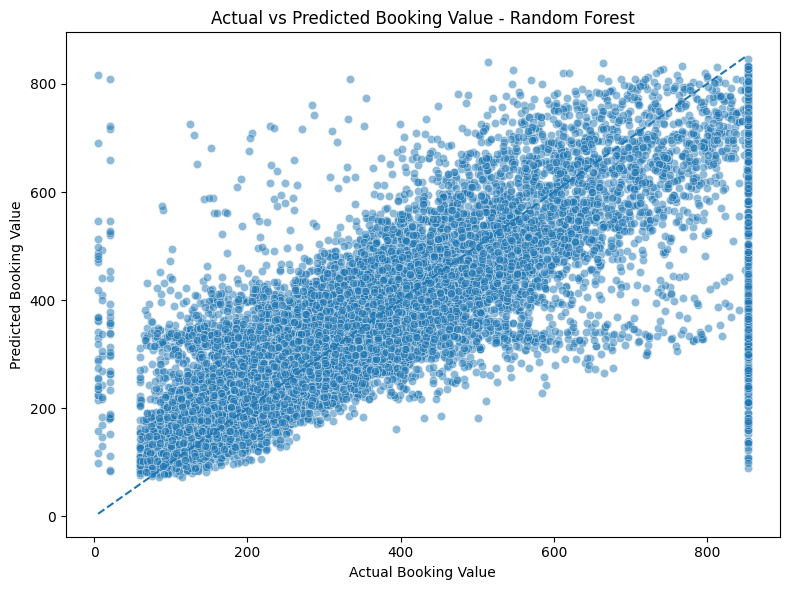

In [221]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.5
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Booking Value - Random Forest")
plt.xlabel("Actual Booking Value")
plt.ylabel("Predicted Booking Value")

plt.tight_layout()
plt.show()

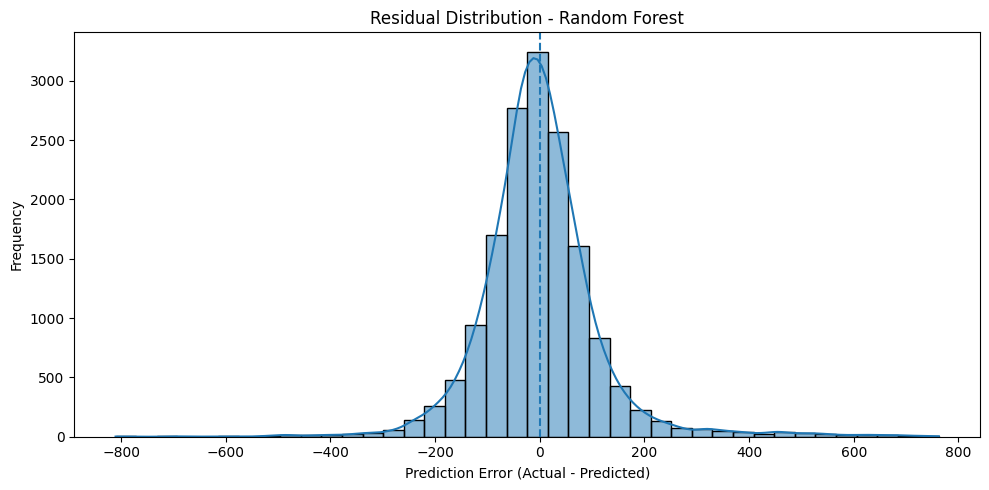

In [222]:
# Calculate residuals
residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Residual Distribution - Random Forest")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

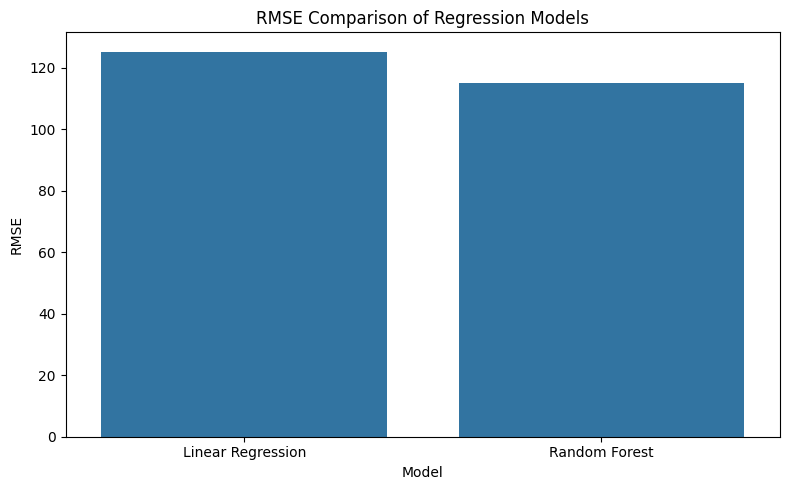

In [223]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

In [224]:
# Final model comparison
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

display(results_df.round(3))

,Model,MAE,MSE,RMSE,R² Score
0,Random Forest,77.186,13234.601,115.042,0.670
1,Linear Regression,83.517,15701.873,125.307,0.609


## Model Evaluation Summary

Two regression models were developed to predict the Booking Value of Uber rides:

- Linear Regression
- Random Forest Regressor

The models were evaluated using MAE, MSE, RMSE, and R² Score.

Random Forest achieved a lower MAE, MSE, and RMSE, along with a higher R² Score compared with Linear Regression on the test dataset.

This indicates that Random Forest was able to capture the non-linear relationships between ride characteristics and Booking Value more effectively than the linear model.

The final model performance was evaluated only on the unseen test dataset.

In [225]:
# Get the trained Random Forest model
rf_model = random_forest_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Show top 15 features
display(feature_importance.head(15))

,Feature,Importance
2,num__Ride Distance,0.761728
1,num__Avg CTAT,0.057518
0,num__Avg VTAT,0.027884
5,num__hour,0.016535
33,cat__Pickup Location_igi airport,0.013585
64,cat__Drop Location_igi airport,0.013278
3,num__Driver Ratings,0.009932
4,num__Customer Rating,0.009642
7,num__month,0.008667
6,num__day_of_week,0.006267


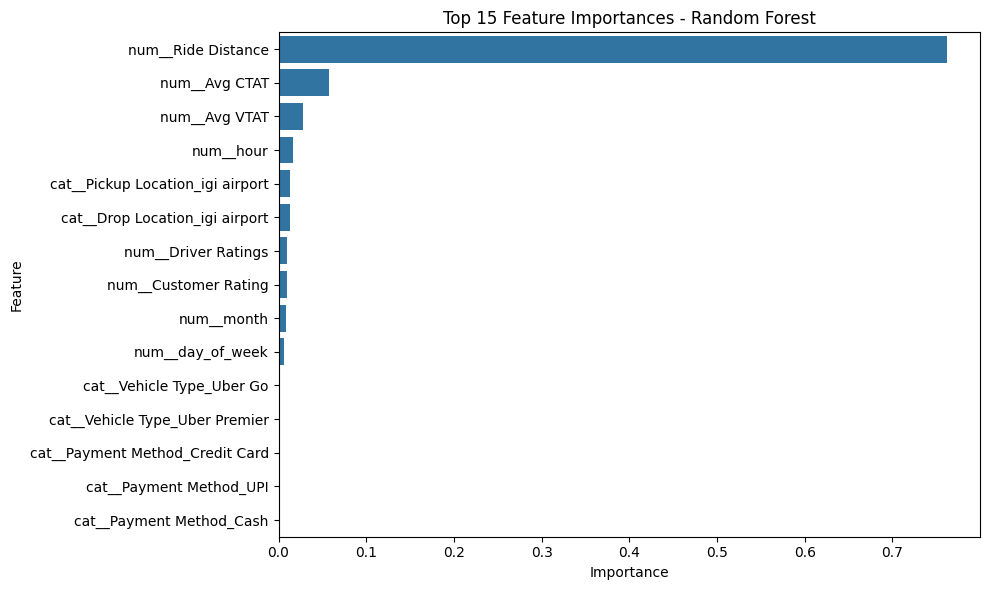

In [226]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Machine Learning Conclusion

The objective of the machine learning task was to predict the Booking Value of an Uber ride.

Two regression models were trained and evaluated:

1. Linear Regression
2. Random Forest Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Random Forest achieved:

- MAE: **77.19**
- MSE: **13,234.60**
- RMSE: **115.04**
- R² Score: **0.670**

Linear Regression achieved:

- MAE: **83.52**
- MSE: **15,701.87**
- RMSE: **125.31**
- R² Score: **0.609**

Therefore, on this test dataset, Random Forest produced lower prediction errors and a higher R² Score than Linear Regression.

The feature importance analysis also helps identify which ride-related features contribute most to the Random Forest predictions.

Overall, the machine learning analysis demonstrates that ride characteristics such as distance, vehicle type, timing, ratings, and location-related features can be used to predict Uber Booking Value.

# Overall Project Conclusion

This project analyzed a large Uber ride dataset to understand booking patterns, customer and driver cancellations, ride characteristics, and factors affecting Booking Value.

### Key Findings

- Most rides in the dataset were **Completed**.
- **Uber Go** and **Uber Auto** were among the most frequently used vehicle types.
- **UPI** was the most frequently used payment method.
- Booking demand varied across different hours, days, and months.
- Customer, driver, and incomplete ride cancellation reasons were analyzed separately.
- Pickup and drop locations helped identify the most frequently used locations and routes.
- Ride Distance showed an important relationship with Booking Value.
- Different vehicle types and payment methods showed differences in average Booking Value.
- Correlation and feature analysis helped identify numerical and categorical factors related to Booking Value.

### Machine Learning Findings

Two regression models were developed to predict Booking Value:

- Linear Regression
- Random Forest Regressor

Random Forest achieved a lower MAE and RMSE and a higher R² Score than Linear Regression on the test dataset.

The Random Forest model achieved an **R² Score of approximately 0.67**, indicating that the model explained a substantial portion of the variation in Booking Value.

### Final Takeaway

The project demonstrates how data cleaning, exploratory data analysis, feature engineering, visualization, and machine learning can be combined to extract useful insights from a large ride-booking dataset and build a regression model for predicting Booking Value.

# Key Insights

### Data & EDA
- The dataset contains a large number of Uber ride bookings with information about rides, customers, drivers, vehicles, locations, payments, and cancellations.
- Most bookings were completed successfully.
- Uber Go and Uber Auto were the most frequently used vehicle types.
- UPI was the most frequently used payment method.
- Booking demand varied according to the hour, day of the week, and month.
- Cancellation and incomplete ride reasons provided useful information about unsuccessful bookings.
- Ride Distance showed an important relationship with Booking Value.
- Booking Value varied across different vehicle types and payment methods.

### Machine Learning
- Booking Value was selected as the regression target.
- Linear Regression was used as a simple baseline model.
- Random Forest Regressor was used to capture non-linear relationships.
- Missing feature values were handled using imputation.
- Categorical variables were converted using One-Hot Encoding.
- `booking_value_per_km` was excluded from the ML features because it is directly calculated using Booking Value and could cause target leakage.
- Random Forest achieved an R² Score of approximately **0.67** on the test dataset.

### Overall Insight

The analysis shows that ride characteristics, distance, vehicle type, timing, ratings, and location-related information can provide useful signals for predicting Uber Booking Value.